In [1]:
pip install cdsapi matplotlib

Note: you may need to restart the kernel to use updated packages.


# Downloading Data

In [2]:
from pathlib import Path

import cdsapi

# Data will be downloaded here.
download_path = Path("~/Projects/aurora-sst/inference/Inference codes")

c = cdsapi.Client()

download_path = download_path.expanduser()
download_path.mkdir(parents=True, exist_ok=True)

# Download the static variables.
if not (download_path / "static.nc").exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "geopotential",
                "land_sea_mask",
                "soil_type",
            ],
            "year": "2025",
            "month": "01",
            "day": "01",
            "time": "00:00",
            "format": "netcdf",
        },
        str(download_path / "static.nc"),
    )
print("Static variables downloaded!")

# Download the surface-level variables.
if not (download_path / "2025-01-01-surface-level.nc").exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "2m_temperature",
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "mean_sea_level_pressure",
                "sea_surface_temperature"
            ],
            "year": "2025",
            "month": "01",
            "day": "01",
            "time": ["00:00", "06:00", "12:00", "18:00"],
            "format": "netcdf",
        },
        str(download_path / "2025-01-01-surface-level.nc"),
    )
print("Surface-level variables downloaded!")

# Download the atmospheric variables.
if not (download_path / "2025-01-01-atmospheric.nc").exists():
    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "temperature",
                "u_component_of_wind",
                "v_component_of_wind",
                "specific_humidity",
                "geopotential",
            ],
            "pressure_level": [
                "50",
                "100",
                "150",
                "200",
                "250",
                "300",
                "400",
                "500",
                "600",
                "700",
                "850",
                "925",
                "1000",
            ],
            "year": "2025",
            "month": "01",
            "day": "01",
            "time": ["00:00", "06:00", "12:00", "18:00"],
            "format": "netcdf",
        },
        str(download_path / "2025-01-01-atmospheric.nc"),
    )
print("Atmospheric variables downloaded!")

2025-11-10 13:05:36,118 INFO Request ID is de9b4724-7c91-4c03-b3f0-a8bfeb9ad3fa
2025-11-10 13:05:36,275 INFO status has been updated to accepted
2025-11-10 13:05:45,014 INFO status has been updated to running
2025-11-10 13:05:50,210 INFO status has been updated to successful


690c4945b13da31d3baeb7382c1a49ff.nc:   0%|          | 0.00/3.34M [00:00<?, ?B/s]

Static variables downloaded!


2025-11-10 13:06:03,715 INFO Request ID is 716828c5-6d58-407a-a3c9-4ae098495026
2025-11-10 13:06:03,848 INFO status has been updated to accepted
2025-11-10 13:06:20,169 INFO status has been updated to running
2025-11-10 13:06:27,909 INFO status has been updated to successful


5f26d692b8fcf158063821ddb9aefdee.nc:   0%|          | 0.00/30.1M [00:00<?, ?B/s]

Surface-level variables downloaded!


2025-11-10 13:06:34,019 INFO Request ID is a972e7d5-613c-489a-8aa3-e04e07851213
2025-11-10 13:06:34,156 INFO status has been updated to accepted
2025-11-10 13:06:45,208 INFO status has been updated to running
2025-11-10 13:08:38,441 INFO status has been updated to successful


201a17977af3ce97691ab0c5b8244329.nc:   0%|          | 0.00/423M [00:00<?, ?B/s]

Atmospheric variables downloaded!


# Visualizing Data, Gap Filling and Batching the Data

In [9]:
import torch
import xarray as xr

from aurora import Batch, Metadata

static_vars_ds = xr.open_dataset(download_path / "static.nc", engine="netcdf4")
surf_vars_ds = xr.open_dataset(download_path / "2025-01-01-surface-level.nc", engine="netcdf4")
atmos_vars_ds = xr.open_dataset(download_path / "2025-01-01-atmospheric.nc", engine="netcdf4")



In [10]:
print(static_vars_ds)

<xarray.Dataset> Size: 12MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2025-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    z           (valid_time, latitude, longitude) float32 4MB ...
    lsm         (valid_time, latitude, longitude) float32 4MB ...
    slt         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-10T16:35 GRIB to CDM+CF via cfgrib-0.9.1...


In [11]:
print(surf_vars_ds)

<xarray.Dataset> Size: 83MB
Dimensions:     (valid_time: 4, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 32B 2025-01-01 ... 2025-01-01T18:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      (valid_time) <U4 64B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 17MB ...
    u10         (valid_time, latitude, longitude) float32 17MB ...
    v10         (valid_time, latitude, longitude) float32 17MB ...
    msl         (valid_time, latitude, longitude) float32 17MB ...
    sst         (valid_time, latitude, longitude) float32 17MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Cen

In [12]:
print(atmos_vars_ds)

<xarray.Dataset> Size: 1GB
Dimensions:         (valid_time: 4, pressure_level: 13, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2025-01-01 ... 2025-01-01...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
    expver          (valid_time) <U4 64B ...
Data variables:
    t               (valid_time, pressure_level, latitude, longitude) float32 216MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 216MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 216MB ...
    q               (valid_time, pressure_level, latitude, longitude) float32 216MB ...
    z               (valid_time, pressure_level, latitude, longitude) float32 216MB ...
Att

In [13]:
surf_vars_ds['sst']

<xarray.DataArray 'sst' (valid_time: 4, latitude: 721, longitude: 1440)> Size: 17MB
[4152960 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 32B 2025-01-01 ... 2025-01-01T18:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      (valid_time) <U4 64B ...
Attributes: (12/31)
    GRIB_paramId:                             34
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           sst
    GRIB_units:                               K
    long_name:                                Sea surface temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [14]:
sst = surf_vars_ds["sst"]  # Kelvin
sst_celsius = sst - 273.15
print(sst_celsius)

<xarray.DataArray 'sst' (valid_time: 4, latitude: 721, longitude: 1440)> Size: 17MB
array([[[-1.6895447, -1.6895447, -1.6895447, ..., -1.6895447,
         -1.6895447, -1.6895447],
        [-1.6895447, -1.6905212, -1.6905212, ..., -1.6895447,
         -1.6895447, -1.6895447],
        [-1.6895447, -1.6895447, -1.6895447, ..., -1.6895447,
         -1.6895447, -1.6895447],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.6895447, -1.6895447, -1.6895447, ..., -1.6895447,
         -1.6895447, -1.6895447],
        [-1.6895447, -1.6905212, -1.6905212, ..., -1.6895447,
         -1.6895447, -1.6895447],
        [-1.6895447, -1.6895447, -1.6895447, ..., -1.6895447,
         -1.6895447, -1.6895447],
...
        [       nan,        nan, 

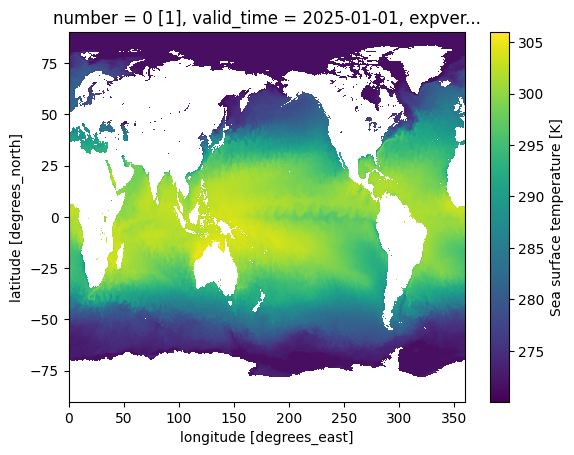

In [15]:
sst.isel(valid_time=0).plot()

In [17]:
print("Mean:", float(sst_celsius.mean().values))
print("Median:", float(sst_celsius.median().values))
print("Standard Deviation:", float(sst_celsius.std().values))
print("Min:", float(sst_celsius.min().values))
print("Max:", float(sst_celsius.max().values))


Mean: 13.992977142333984
Median: 15.484283447265625
Standard Deviation: 11.665152549743652
Min: -3.071380615234375
Max: 34.640533447265625


In [19]:
missing_count = int(sst_celsius.isnull().sum().values)
valid_count = int(sst_celsius.notnull().sum().values)
total_points = sst_celsius.size


print("Total grid points:", total_points)
print("Missing values:", missing_count)
print("Valid values:", valid_count)


Total grid points: 4152960
Missing values: 1407504
Valid values: 2745456


In [22]:
print("Mean:", float(sst.mean().values))
print("Median:", float(sst.median().values))
print("Standard Deviation:", float(sst.std().values))
print("Min:", float(sst.min().values))
print("Max:", float(sst.max().values))


Mean: 287.1429748535156
Median: 288.63427734375
Standard Deviation: 11.665152549743652
Min: 270.07861328125
Max: 307.79052734375


Gap Filling

In [23]:
# Compute median while ignoring NaNs
sst_median = float(sst.median().values)

# Fill missing values with median
sst_filled = sst.fillna(sst_median)

In [24]:
missing_count = int(sst_filled.isnull().sum().values)
valid_count = int(sst_filled.notnull().sum().values)
total_points = sst_filled.size


print("Total grid points:", total_points)
print("Missing values:", missing_count)
print("Valid values:", valid_count)


Total grid points: 4152960
Missing values: 0
Valid values: 4152960


In [27]:
print("Mean:", float(sst_filled.mean().values))
print("Median:", float(sst_filled.median().values))
print("Standard Deviation:", float(sst_filled.std().values))
print("Min:", float(sst_filled.min().values))
print("Max:", float(sst_filled.max().values))

Mean: 287.64837646484375
Median: 288.63427734375
Standard Deviation: 9.51082706451416
Min: 270.07861328125
Max: 307.79052734375


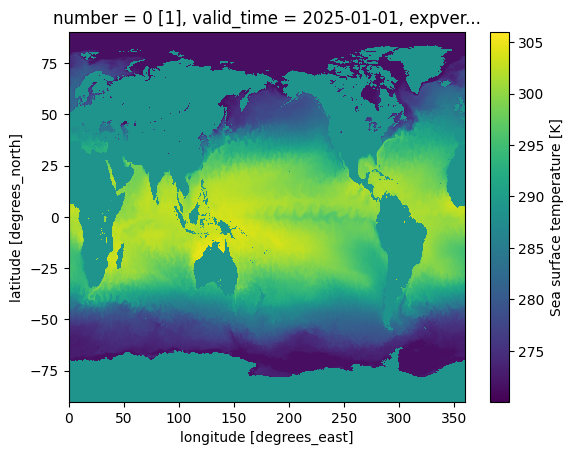

In [26]:
sst_filled.isel(valid_time=0).plot()

In [28]:
from aurora.normalisation import locations, scales

locations["sst"] = float(sst_filled.mean().values)  # e.g.,  mean of your SST data
scales["sst"] = float(sst_filled.std().values)      # e.g., standard deviation of SST


Batching the Data

In [30]:
batch = Batch(
    surf_vars={
        # First select the first two time points: 00:00 and 06:00. Afterwards, `[None]`
        # inserts a batch dimension of size one.
        "2t": torch.from_numpy(surf_vars_ds["t2m"].values[:2][None]),
        "10u": torch.from_numpy(surf_vars_ds["u10"].values[:2][None]),
        "10v": torch.from_numpy(surf_vars_ds["v10"].values[:2][None]),
        "msl": torch.from_numpy(surf_vars_ds["msl"].values[:2][None]),
        "sst": torch.from_numpy(sst_filled.values[:2][None]),  # gap-filled SST
    },
    static_vars={
        # The static variables are constant, so we just get them for the first time.
        "z": torch.from_numpy(static_vars_ds["z"].values[0]),
        "slt": torch.from_numpy(static_vars_ds["slt"].values[0]),
        "lsm": torch.from_numpy(static_vars_ds["lsm"].values[0]),
    },
    atmos_vars={
        "t": torch.from_numpy(atmos_vars_ds["t"].values[:2][None]),
        "u": torch.from_numpy(atmos_vars_ds["u"].values[:2][None]),
        "v": torch.from_numpy(atmos_vars_ds["v"].values[:2][None]),
        "q": torch.from_numpy(atmos_vars_ds["q"].values[:2][None]),
        "z": torch.from_numpy(atmos_vars_ds["z"].values[:2][None]),
    },
    metadata=Metadata(
        lat=torch.from_numpy(surf_vars_ds.latitude.values),
        lon=torch.from_numpy(surf_vars_ds.longitude.values),
        # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
        # `datetime.datetime`s. Note that this needs to be a tuple of length one:
        # one value for every batch element. Select element 1, corresponding to time
        # 06:00.
        time=(surf_vars_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
        atmos_levels=tuple(int(level) for level in atmos_vars_ds.pressure_level.values),
    ),
)

# Codes for inference on SST data -- Not To Run

In [ ]:
from aurora import Aurora, rollout


model = Aurora(use_lora=False)  # The pretrained version does not use LoRA.
model.load_checkpoint("microsoft/aurora", "aurora-0.25-pretrained.ckpt")

model.eval()
model = model.to("cuda")

with torch.inference_mode():
    preds = [pred.to("cpu") for pred in rollout(model, batch, steps=2)]




model = model.to("cpu")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ocean mask: True for ocean, False for land
ocean_mask = static_vars_ds["lsm"].values == 0

fig, ax = plt.subplots(2, 2, figsize=(12, 6.5))

for i in range(ax.shape[0]):
    pred = preds[i]

    # Predicted SST in Celsius
    sst_pred_c = pred.surf_vars["sst"][0, 0].numpy() - 273.15
    sst_pred_c_masked = np.where(ocean_mask, sst_pred_c, np.nan)
    ax[i, 0].imshow(sst_pred_c_masked, vmin=-50, vmax=50)
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Predicted SST")
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    # Original SST in Celsius
    sst_orig_c = sst.values[2 + i] - 273.15
    #sst_orig_c_masked = np.where(ocean_mask, sst_orig_c, np.nan)
    ax[i, 1].imshow(sst_orig_c, vmin=-50, vmax=50)
    if i == 0:
        ax[i, 1].set_title("SST") 
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])

plt.tight_layout()

# Save figure as PNG
plt.savefig("sst_comparison.png", dpi=300)
plt.close(fig)  # Close the figure to free memory


# Evaluation

In [ ]:
import numpy as np

# latitudes in degrees from the dataset
lat = surf_vars_ds.latitude.values  # shape: [H]

# Compute cos(lat) in radians
weights = np.cos(np.deg2rad(lat))

# Normalize to unit mean
weights /= weights.mean()  # shape: [H]


def weighted_rmse(pred, true, weights):
    """
    pred, true: [time, lat, lon], may contain NaNs
    weights: [lat]
    """
    w = weights[:, None]  # [lat,1]

    # Mask invalid points
    mask = ~np.isnan(pred)
    
    se = (pred - true)**2
    se[~mask] = 0  # ignore NaNs
    
    # Apply weights
    weighted_se = se * w[None, :, :]
    
    # Normalize by sum of weights over valid points
    rmse = np.sqrt(np.sum(weighted_se) / np.sum(w[None, :, :] * mask))
    
    return rmse



sst_pred = np.stack([p.surf_vars["sst"][0, 0].numpy() for p in preds])  # [time, lat, lon]
# Mask predicted SST to ocean only (land = NaN)
sst_pred = np.where(ocean_mask, sst_pred, np.nan)
sst_true = sst.values[2:2+sst_pred.shape[0]]  # align with prediction time steps

rmse = weighted_rmse(sst_pred, sst_true, weights)
print("Weighted RMSE:", rmse)


def weighted_acc(pred, true, climatology, weights):
    """
    pred, true, climatology: [time, lat, lon], may contain NaNs
    weights: [lat]
    """
    w = weights[:, None]  # [lat,1]
    acc_list = []

    for t in range(pred.shape[0]):
        pred_anom = pred[t] - climatology[t]
        true_anom = true[t] - climatology[t]

        # Ignore NaNs
        mask = ~np.isnan(pred_anom)  # NaNs in pred indicate land points
        pred_anom = np.where(mask, pred_anom, 0)
        true_anom = np.where(mask, true_anom, 0)

        numerator = np.sum(w * pred_anom * true_anom)
        denominator = np.sqrt(np.sum(w * pred_anom**2) * np.sum(w * true_anom**2))
        acc_list.append(numerator / denominator)

    return np.mean(acc_list)



# Daily climatology: same shape as sst_pred
# For simplicity, mean over available ERA5 time steps
sst_climatology = np.nanmean(sst.values, axis=0)[None, :, :]
sst_climatology = np.repeat(sst_climatology, sst_pred.shape[0], axis=0)

acc = weighted_acc(sst_pred, sst_true, sst_climatology, weights)
print("Weighted ACC:", acc)

